# Import các thư viện cần thiết

In [24]:
# Regex được dùng để chuẩn hóa các chuỗi chứa khoảng thời gian ngủ.
import re
from pathlib import Path

# Thư viện xử lý dữ liệu và trực quan hóa.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Các thành phần xây dựng pipeline preprocessing tái lập trên train/test.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Đọc dữ liệu
Nạp đồng thời `train.csv`, `test.csv`, và `sample_submission.csv` để kiểm tra schema ngay từ đầu và giữ đúng cấu trúc cho bước submission sau này.

In [25]:
# Khai báo đường dẫn và tên các cột đặc biệt để dùng thống nhất ở toàn notebook.
DATA_PATH = Path('../data')
TARGET_COL = 'Depression'
ID_COL = 'id'

# Đọc train, test và submission mẫu bằng notebook-relative path.
train_df = pd.read_csv(DATA_PATH / 'train.csv')
test_df = pd.read_csv(DATA_PATH / 'test.csv')
sample_submission = pd.read_csv(DATA_PATH / 'sample_submission.csv')

# In kích thước để xác nhận số dòng và số cột đúng với kỳ vọng của đề bài.
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Sample submission shape: {sample_submission.shape}')

# In schema ngắn gọn để quan sát kiểu dữ liệu thô trước khi làm sạch.
schema_overview = pd.DataFrame({
    'train_dtype': train_df.dtypes.astype(str),
    'test_dtype': test_df.dtypes.astype(str).reindex(train_df.columns, fill_value='not_in_test')
})
print(schema_overview.head(10).to_string())

# Hiển thị vài dòng đầu để quan sát trực tiếp dữ liệu gốc.
train_df.head()

Train shape: (140700, 20)
Test shape: (93800, 19)
Sample submission shape: (93800, 2)
                                train_dtype test_dtype
id                                    int64      int64
Name                                    str        str
Gender                                  str        str
Age                                 float64    float64
City                                    str        str
Working Professional or Student         str        str
Profession                              str        str
Academic Pressure                   float64    float64
Work Pressure                       float64    float64
CGPA                                float64    float64


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


# Missing values
Tỷ lệ thiếu của từng cột được tính theo công thức:
$$
\text{missing\_pct}_j = \frac{\sum_{i=1}^{n} \mathbb{1}(x_{ij}\text{ is NaN})}{n} \times 100
$$
Mục tiêu của bước này là phân biệt missing do dữ liệu thật sự thiếu với missing do cột không áp dụng cho từng nhóm đối tượng.

In [26]:
# Đếm số lượng giá trị thiếu theo từng cột của tập train.
missing_summary = (
    train_df.isna()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda frame: (frame['missing_count'] / len(train_df) * 100).round(2))
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)

# In thêm tổng số ô bị thiếu để có cảm giác về mức độ nghiêm trọng của missingness.
total_missing_cells = int(train_df.isna().sum().sum())
print(f'Total missing cells in train: {total_missing_cells}')

# Hiển thị bảng missing đầy đủ để quan sát các cột cần xử lý trước tiên.
missing_summary

Total missing cells in train: 430876


,missing_count,missing_pct
Academic Pressure,112803,80.17
Study Satisfaction,112803,80.17
CGPA,112802,80.17
Profession,36630,26.03
Work Pressure,27918,19.84
Job Satisfaction,27910,19.84
Dietary Habits,4,0.00
Financial Stress,4,0.00
Degree,2,0.00


# Unique values trong các cột phân loại
Số lượng category giúp nhận diện cột high-cardinality và những cột có khả năng chứa label nhiễu. Đây là cơ sở để quyết định cột nào cần gom nhóm category hiếm hoặc loại bỏ.

Top categorical cardinality:
                                       unique_count
Name                                            422
Degree                                          115
City                                             98
Profession                                       64
Sleep Duration                                   36
Dietary Habits                                   23
Gender                                            2
Working Professional or Student                   2
Have you ever had suicidal thoughts ?             2
Family History of Mental Illness                  2


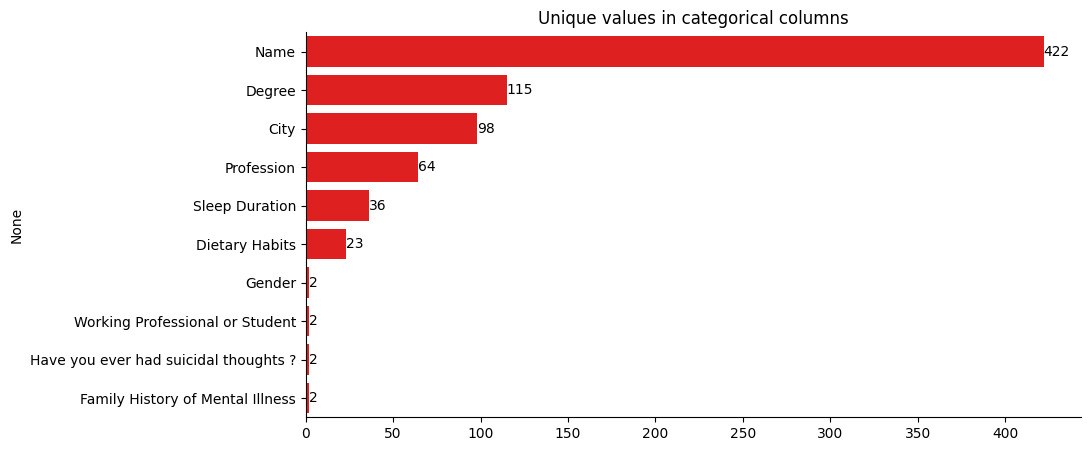

In [27]:
# Chọn các cột phân loại ban đầu, bỏ cột target để tránh đánh giá nhầm cardinality.
feature_cat_cols = train_df.drop(columns=[TARGET_COL]).select_dtypes(include=['object', 'string']).columns.tolist()

# Tính số category khác nhau trên từng cột phân loại.
cat_cardinality = train_df[feature_cat_cols].nunique(dropna=True).sort_values(ascending=False)
print('Top categorical cardinality:')
print(cat_cardinality.to_frame('unique_count').head(10).to_string())

# Vẽ biểu đồ để nhìn nhanh cột nào có cardinality cao bất thường.
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=cat_cardinality.values,
    y=cat_cardinality.index,
    ax=ax,
    color='red',
)
ax.set_title('Unique values in categorical columns')

# Gắn nhãn số lượng trực tiếp lên biểu đồ để tiện đối chiếu.
for i, value in enumerate(cat_cardinality.values):
    ax.text(value, i, f'{value}', va='center')

sns.despine()
plt.show()

# Tổng quan preprocessing
Mục tiêu là xây dựng một hàm tiền xử lý duy nhất $T(\cdot)$ sao cho train và test đi qua cùng một quy trình, nhưng mọi tham số chỉ được fit trên train:
$$
X_{train}^{*} = T(X_{train}), \quad X_{test}^{*} = T(X_{test})
$$
Với các cột chỉ áp dụng theo vai trò, ta dùng quy tắc role-aware trước khi impute:
$$
x_{ij}^{role} = \begin{cases}
0, & \text{nếu cột không áp dụng cho vai trò của dòng } i \\
x_{ij}, & \text{nếu cột áp dụng và đã quan sát được} \\
\text{NaN}, & \text{nếu cột áp dụng nhưng còn thiếu để xử lý ở bước sau}
\end{cases}
$$

In [28]:
# Chọn cột vai trò để đo missingness theo đúng ngữ cảnh Student/Working Professional.
role_col = 'Working Professional or Student'
role_specific_columns = [
    'Academic Pressure',
    'Study Satisfaction',
    'CGPA',
    'Work Pressure',
    'Job Satisfaction',
    'Profession',
]

# Tạo bảng missing theo role để phân biệt missing do không áp dụng và missing thực sự cần xử lý.
role_missing_summary = pd.DataFrame(
    {
        'student_missing': train_df.loc[train_df[role_col] == 'Student', role_specific_columns].isna().sum(),
        'working_missing': train_df.loc[train_df[role_col] == 'Working Professional', role_specific_columns].isna().sum(),
    }
)

# Lấy các giá trị hiếm hoặc dị thường ở cột Sleep Duration để xây luật làm sạch.
sleep_rare_values = train_df['Sleep Duration'].value_counts(dropna=False)
sleep_rare_values = sleep_rare_values[sleep_rare_values <= 5].sort_values()

# Lấy các giá trị hiếm hoặc dị thường ở cột Dietary Habits để xây luật làm sạch.
diet_rare_values = train_df['Dietary Habits'].value_counts(dropna=False)
diet_rare_values = diet_rare_values[diet_rare_values <= 5].sort_values()

print('Columns with missing values:')
print(missing_summary.index.tolist())
print('\nMissing values by role:')
print(role_missing_summary.to_string())
print('\nRare Sleep Duration values (count <= 5):')
print(sleep_rare_values.to_frame('count').to_string())
print('\nRare Dietary Habits values (count <= 5):')
print(diet_rare_values.to_frame('count').to_string())

Columns with missing values:
['Academic Pressure', 'Study Satisfaction', 'CGPA', 'Profession', 'Work Pressure', 'Job Satisfaction', 'Dietary Habits', 'Financial Stress', 'Degree']

Missing values by role:
                    student_missing  working_missing
Academic Pressure                 9           112794
Study Satisfaction               10           112793
CGPA                              9           112793
Work Pressure                 27898               20
Job Satisfaction              27893               17
Profession                    27867             8763

Rare Sleep Duration values (count <= 5):
                  count
Sleep Duration         
40-45 hours           1
Moderate              1
55-66 hours           1
9-6 hours             1
1-2 hours             1
9-5                   1
45-48 hours           1
3-6 hours             1
Work_Study_Hours      1
49 hours              1
than 5 hours          1
10-6 hours            1
8 hours               1
35-36 hours           

# Làm sạch dữ liệu thô
Bước này chuẩn hóa các giá trị phân loại bị nhiễu, xử lý các cột chỉ áp dụng cho Student hoặc Working Professional, và gom các category hiếm để train/test nhất quán.
Ý tưởng là giảm nhiễu trước khi fit pipeline để encoder nhìn thấy category sạch hơn và ít bị nổ số chiều do label sai.

In [29]:
# Khai báo các nhóm cột để tách logic xử lý theo vai trò và theo kiểu dữ liệu.
ROLE_COL = 'Working Professional or Student'
STUDENT_ONLY_NUMERIC_COLS = ['Academic Pressure', 'Study Satisfaction', 'CGPA']
WORKING_ONLY_NUMERIC_COLS = ['Work Pressure', 'Job Satisfaction']
GENERAL_NUMERIC_COLS = ['Age', 'Work/Study Hours', 'Financial Stress']
HIGH_CARDINALITY_COLS = ['City', 'Profession', 'Degree']
DROP_COLS = ['Name']

# Chuẩn hóa khoảng trắng ở toàn bộ cột chuỗi để tránh tạo category trùng nghĩa.
def strip_object_columns(frame):
    frame = frame.copy()
    object_cols = frame.select_dtypes(include=['object', 'string']).columns
    for col in object_cols:
        frame[col] = frame[col].map(lambda value: value.strip() if isinstance(value, str) else value)
    return frame

# Chuẩn hóa cột Yes/No và đẩy giá trị lạ về Unknown.
def clean_yes_no(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value == 'yes':
        return 'Yes'
    if value == 'no':
        return 'No'
    return 'Unknown'

# Chuẩn hóa cột giới tính để giữ số category ổn định.
def clean_gender(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value == 'male':
        return 'Male'
    if value == 'female':
        return 'Female'
    return 'Unknown'

# Chuẩn hóa cột role để dùng như khóa cho role-aware preprocessing.
def clean_role(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if 'student' in value:
        return 'Student'
    if 'working' in value:
        return 'Working Professional'
    return 'Unknown'

# Gom các biểu diễn thời lượng ngủ về 4 mức chính và loại bỏ giá trị vô lý.
def clean_sleep_duration(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if not value:
        return np.nan
    lowered = value.lower()
    if 'less than 5' in lowered or 'than 5 hours' in lowered:
        return 'Less than 5 hours'
    if 'more than 8' in lowered:
        return 'More than 8 hours'
    if 'hour' not in lowered:
        return 'Unknown'

    range_match = re.search(r'(\d{1,2})\s*-\s*(\d{1,2})\s*hours?', lowered)
    single_match = re.search(r'(\d{1,2})(?:\.\d+)?\s*hours?', lowered)

    if range_match:
        start, end = map(float, range_match.groups())
        avg_hours = (start + end) / 2
    elif single_match:
        avg_hours = float(single_match.group(1))
    else:
        return 'Unknown'

    if avg_hours <= 0 or avg_hours > 16:
        return 'Unknown'
    if avg_hours < 5:
        return 'Less than 5 hours'
    if avg_hours < 7:
        return '5-6 hours'
    if avg_hours <= 8:
        return '7-8 hours'
    return 'More than 8 hours'

# Gom thói quen ăn uống về 3 mức chính và đẩy giá trị nhiễu về Unknown.
def clean_dietary_habits(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if not value:
        return np.nan
    lowered = value.lower()
    if 'unhealthy' in lowered:
        return 'Unhealthy'
    if 'moderate' in lowered:
        return 'Moderate'
    if 'healthy' in lowered:
        return 'Healthy'
    return 'Unknown'

# Gom category hiếm theo train để tránh để test sinh ra các nhãn riêng lẻ ngoài ý muốn.
def collapse_rare_categories(train_series, test_series, min_count=20, missing_label='Missing', other_label='Other'):
    train_series = train_series.fillna(missing_label)
    test_series = test_series.fillna(missing_label)

    value_counts = train_series.value_counts()
    keep_values = set(value_counts[value_counts >= min_count].index)
    keep_values.add(missing_label)

    train_series = train_series.where(train_series.isin(keep_values), other_label)
    test_series = test_series.where(test_series.isin(keep_values), other_label)
    return train_series, test_series

# Áp dụng toàn bộ luật làm sạch cho train và test theo cùng một quy trình.
def prepare_features(train_frame, test_frame):
    train_clean = strip_object_columns(train_frame)
    test_clean = strip_object_columns(test_frame)

    for frame in (train_clean, test_clean):
        # Chuẩn hóa các cột phân loại cơ bản trước khi tách numeric/categorical.
        frame[ROLE_COL] = frame[ROLE_COL].apply(clean_role)
        frame['Gender'] = frame['Gender'].apply(clean_gender)
        frame['Have you ever had suicidal thoughts ?'] = frame['Have you ever had suicidal thoughts ?'].apply(clean_yes_no)
        frame['Family History of Mental Illness'] = frame['Family History of Mental Illness'].apply(clean_yes_no)
        frame['Sleep Duration'] = frame['Sleep Duration'].apply(clean_sleep_duration)
        frame['Dietary Habits'] = frame['Dietary Habits'].apply(clean_dietary_habits)

        # Ép kiểu numeric để các bước thống kê và imputation hoạt động đúng.
        numeric_cols = STUDENT_ONLY_NUMERIC_COLS + WORKING_ONLY_NUMERIC_COLS + GENERAL_NUMERIC_COLS
        for col in numeric_cols:
            frame[col] = pd.to_numeric(frame[col], errors='coerce')

        # Xác định mask theo role để xử lý các cột chỉ áp dụng cho từng nhóm.
        student_mask = frame[ROLE_COL] == 'Student'
        working_mask = frame[ROLE_COL] == 'Working Professional'

        # Với cột chỉ dành cho Student, các dòng Working Professional được gán 0.
        for col in STUDENT_ONLY_NUMERIC_COLS:
            frame[f'{col} Missing Relevant'] = (student_mask & frame[col].isna()).astype(int)
            frame.loc[working_mask, col] = 0

        # Với cột chỉ dành cho Working Professional, các dòng Student được gán 0.
        for col in WORKING_ONLY_NUMERIC_COLS:
            frame[f'{col} Missing Relevant'] = (working_mask & frame[col].isna()).astype(int)
            frame.loc[student_mask, col] = 0

        # Profession chỉ có ý nghĩa mạnh hơn với Working Professional nên cần gắn nhãn riêng.
        frame['Profession Missing Relevant'] = (working_mask & frame['Profession'].isna()).astype(int)
        frame.loc[student_mask, 'Profession'] = 'Not applicable'
        frame.loc[working_mask & frame['Profession'].isna(), 'Profession'] = 'Unknown'

        # Điền Unknown cho các cột phân loại chuẩn hóa để encoder không gặp NaN trực tiếp.
        for col in ['Gender', ROLE_COL, 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Sleep Duration', 'Dietary Habits']:
            frame[col] = frame[col].fillna('Unknown')

    # Gom category hiếm dựa trên train để test bám đúng không gian category đã học.
    for col in HIGH_CARDINALITY_COLS:
        train_clean[col], test_clean[col] = collapse_rare_categories(train_clean[col], test_clean[col], min_count=20)

    # Loại bỏ Name vì cardinality cao và khó tạo tín hiệu ổn định cho mô hình.
    train_clean = train_clean.drop(columns=DROP_COLS)
    test_clean = test_clean.drop(columns=DROP_COLS)

    return train_clean, test_clean

# Numeric preprocessing
Sau bước role-aware cleaning, các biến số được giữ ở dạng numeric và phần còn thiếu sẽ được median imputation trong pipeline.
Với mỗi biến số $x_j$, giá trị thiếu cuối cùng được thay bởi:
$$
x_j^{imp} = \operatorname{median}(x_j)
$$
Ta in ra thống kê trung gian để quan sát xem còn thiếu ở đâu trước khi fit transformer.

In [30]:
# Áp dụng hàm làm sạch cho train và test bằng cùng một quy tắc.
train_prepared, test_prepared = prepare_features(train_df, test_df)

# Tách target và id để phần đặc trưng chỉ còn các biến đầu vào cho preprocessing.
y_train = train_prepared[TARGET_COL].copy()
train_ids = train_prepared[ID_COL].copy()
test_ids = test_prepared[ID_COL].copy()

X_train = train_prepared.drop(columns=[ID_COL, TARGET_COL])
X_test = test_prepared.drop(columns=[ID_COL])

# Phân nhóm feature numeric và categorical sau khi làm sạch.
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()

# Tạo các bảng trung gian để quan sát numeric features trước khi fit pipeline.
numeric_missing_after_cleaning = (
    X_train[numeric_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('missing_after_role_cleaning')
)
numeric_profile = X_train[numeric_features].describe().T[['mean', 'std', 'min', 'max']]

print(f'X_train shape before encoding: {X_train.shape}')
print(f'X_test shape before encoding: {X_test.shape}')
print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print('Numeric feature list:')
print(numeric_features)
print('\nTop numeric missing after role-aware cleaning:')
print(numeric_missing_after_cleaning.head(10).to_string())
print('\nNumeric profile preview:')
print(numeric_profile.head(10).to_string())

# Hiển thị vài dòng đầu sau cleaning để kiểm tra logic role-aware đã đi đúng hướng.
X_train.head()

X_train shape before encoding: (140700, 23)
X_test shape before encoding: (93800, 23)
Numeric features: 14
Categorical features: 9
Numeric feature list:
['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Academic Pressure Missing Relevant', 'Study Satisfaction Missing Relevant', 'CGPA Missing Relevant', 'Work Pressure Missing Relevant', 'Job Satisfaction Missing Relevant', 'Profession Missing Relevant']

Top numeric missing after role-aware cleaning:
                                     missing_after_role_cleaning
Work Pressure                                                 20
Job Satisfaction                                              17
Study Satisfaction                                            10
Academic Pressure                                              9
CGPA                                                           9
Financial Stress                                               4
Age 

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,...,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Academic Pressure Missing Relevant,Study Satisfaction Missing Relevant,CGPA Missing Relevant,Work Pressure Missing Relevant,Job Satisfaction Missing Relevant,Profession Missing Relevant
0,Female,49.0,Ludhiana,Working Professional,Chef,0.0,5.0,0.00,0.0,2.0,...,No,1.0,2.0,No,0,0,0,0,0,0
1,Male,26.0,Varanasi,Working Professional,Teacher,0.0,4.0,0.00,0.0,3.0,...,Yes,7.0,3.0,No,0,0,0,0,0,0
2,Male,33.0,Visakhapatnam,Student,Not applicable,5.0,0.0,8.97,2.0,0.0,...,Yes,3.0,1.0,No,0,0,0,0,0,0
3,Male,22.0,Mumbai,Working Professional,Teacher,0.0,5.0,0.00,0.0,1.0,...,Yes,10.0,1.0,Yes,0,0,0,0,0,0
4,Female,30.0,Kanpur,Working Professional,Business Analyst,0.0,1.0,0.00,0.0,1.0,...,Yes,9.0,4.0,Yes,0,0,0,0,0,0


# Categorical encoding
Các biến phân loại được chuẩn hóa label, gom category hiếm, rồi one-hot encoding để giữ thông tin nominal mà không áp đặt thứ tự giả.
Với mỗi category $c_k$, one-hot encoding tạo vector cơ sở $e_k$ sao cho:
$$
\operatorname{OneHot}(c_k) = e_k
$$
Ta in ra phân bố category sau cleaning để kiểm tra các luật chuẩn hóa trước khi fit encoder.

In [31]:
# Tóm tắt cardinality sau cleaning để xem các cột phân loại đã ổn định hơn chưa.
categorical_overview = pd.DataFrame({
    'unique_after_cleaning': X_train[categorical_features].nunique(),
    'mode_after_cleaning': X_train[categorical_features].mode().iloc[0],
}).sort_values('unique_after_cleaning', ascending=False)

print('Categorical feature list:')
print(categorical_features)
print('\nCategorical overview after cleaning:')
print(categorical_overview.to_string())

# In phân bố của các cột dễ nhiễu nhất để quan sát trực tiếp hiệu quả làm sạch.
for column in ['Sleep Duration', 'Dietary Habits', 'City', 'Profession', 'Degree']:
    print(f'\nTop cleaned categories for {column}:')
    print(X_train[column].value_counts(dropna=False).head(10).to_string())

Categorical feature list:
['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

Categorical overview after cleaning:
                                       unique_after_cleaning   mode_after_cleaning
Profession                                                38        Not applicable
City                                                      31                Kalyan
Degree                                                    29              Class 12
Sleep Duration                                             5     Less than 5 hours
Dietary Habits                                             4              Moderate
Gender                                                     2                  Male
Working Professional or Student                            2  Working Professional
Have you ever had suicidal thoughts ?                      2                    N

# Ghép numeric và categorical pipeline
Sau khi đã quan sát riêng từng nhánh, ta ghép chúng vào một `ColumnTransformer` để fit trên train và transform sang test.
Nhánh số dùng median imputation, còn nhánh phân loại dùng most-frequent imputation kết hợp `OneHotEncoder(handle_unknown='ignore')` để tránh lỗi khi test xuất hiện category mới.

In [32]:
# Xây transformer cho nhánh numeric: chỉ median imputation vì dữ liệu đã được role-aware clean.
numeric_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median'))]
)

# Xây transformer cho nhánh categorical: điền mode rồi one-hot encode.
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]
)

# Ghép hai nhánh vào một ColumnTransformer để fit/transform nhất quán.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    sparse_threshold=1.0,
)

# Fit trên train và chỉ transform trên test để tránh leakage.
X_train_matrix = preprocessor.fit_transform(X_train)
X_test_matrix = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Chuyển ma trận sparse về DataFrame sparse để dễ quan sát và dùng cho bước modeling.
X_train_processed = pd.DataFrame.sparse.from_spmatrix(
    X_train_matrix,
    index=train_ids,
    columns=feature_names,
)
X_test_processed = pd.DataFrame.sparse.from_spmatrix(
    X_test_matrix,
    index=test_ids,
    columns=feature_names,
)
y_train.index = train_ids

print(f'Processed train shape: {X_train_processed.shape}')
print(f'Processed test shape: {X_test_processed.shape}')
print(f'Total engineered features: {len(feature_names)}')
print('Preprocessor branches:')
print(preprocessor.transformers_)

# In một preview nhỏ để xác nhận tên cột và giá trị sau transform hợp lý.
preview_columns = feature_names[:10]
preview = pd.DataFrame(
    X_train_matrix[:5, :10].toarray(),
    index=train_ids.iloc[:5],
    columns=preview_columns,
)
print('\nPreview of processed features:')
print(preview.to_string())

# In thêm vài tên feature đầu tiên để quan sát cách encoder mở rộng cột.
print('First 20 engineered features:')
print(feature_names[:20])

Processed train shape: (140700, 129)
Processed test shape: (93800, 129)
Total engineered features: 129
Preprocessor branches:
[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Academic Pressure Missing Relevant', 'Study Satisfaction Missing Relevant', 'CGPA Missing Relevant', 'Work Pressure Missing Relevant', 'Job Satisfaction Missing Relevant', 'Profession Missing Relevant']), ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), ['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'])]

Preview of processed features:
    num__Age  num__Academic Pressure  num__Work Pressure  num__CGPA  num__Study Satis

# Validation cuối
Bước cuối cùng kiểm tra các điều kiện tối thiểu của milestone preprocessing: số dòng không đổi, số cột train/test thẳng hàng, không còn missing sau transform, và `id` vẫn khớp với submission mẫu.
Nếu tất cả điều kiện đều đạt, dữ liệu đã sẵn sàng cho modeling hoặc export ra artifact ở bước sau.

In [33]:
# Đếm số phần tử còn thiếu trong ma trận sparse sau khi preprocessing.
train_missing_after_preprocessing = int(pd.isna(X_train_matrix.data).sum())
test_missing_after_preprocessing = int(pd.isna(X_test_matrix.data).sum())

# Tổng hợp các điều kiện kiểm tra quan trọng nhất cho milestone preprocessing.
validation_summary = pd.Series(
    {
        'train_rows': X_train_processed.shape[0],
        'test_rows': X_test_processed.shape[0],
        'train_features': X_train_processed.shape[1],
        'test_features': X_test_processed.shape[1],
        'column_alignment_ok': list(X_train_processed.columns) == list(X_test_processed.columns),
        'train_missing_after_preprocessing': train_missing_after_preprocessing,
        'test_missing_after_preprocessing': test_missing_after_preprocessing,
        'target_missing': int(y_train.isna().sum()),
        'submission_id_match': sample_submission[ID_COL].equals(test_ids.reset_index(drop=True)),
    }
)

# In bảng kiểm cuối cùng để kết luận notebook đã hoàn tất preprocessing hay chưa.
print(validation_summary.to_string())

train_rows                           140700
test_rows                             93800
train_features                          129
test_features                           129
column_alignment_ok                    True
train_missing_after_preprocessing         0
test_missing_after_preprocessing          0
target_missing                            0
submission_id_match                    True
